In [1]:
import os
import copy
import numpy as np
import scipy
import pandas
import matplotlib.pyplot as plt

# Implementing the SGD

The goal of this tutorial is to implement the Stochastic Gradient Descent (SGD) and to test it on various functions.

## Implementation

**Question 1**

Complete the class `OptimizerSGD` below. This class contains a SGD optimizer with all its parameters:
* `eta0`: starting learning rate;
* `scheduler`: function taking the index of the current iteration (or time) as input and outputting the factor with which we will multiply `eta0`;
* `max_iter`: the maximum number of iterations;
* `patience` and `rtol`: parameters of the stopping criterion. The algorithm should stop if no point `x` has been found in the last `patience` iterations such that `f(x)` is lower than `f(x_best) * (1 - rtol)` (where `x_best` is the current estimate of the minimum of `f`).

By default, the scheduler should be constant.

The methods to implement are:
* `minimize`: the method to call to minimize a function `f`. It takes arguments:
  * `f`: the function to minimize;
  * `df`: its derivative;
  * `x0`: the starting point of the SGD;
  
  Returns the result of the optimization process (best `x`).
* `step`: the method performing each SGD iteration. Arguments: 
  * `df`: derivative of the function `f` to minimize;
  * `x`: the current point $x_n$;
  
  Returns the new point $x_{n+1}$;
* `criterion_continue`: the method checking if the algorithm has converged or not. Arguments:
  * `x`: current point `x`;
  * `y`: `f(x)`.
  
  Returns `True` if the algorithm has not converged, else `False`.

In [2]:
class OptimizerSGD():
    def __init__(self, eta0, scheduler = None,
                max_iter = 100, patience = 5, rtol = 1e-4):
        self.eta0 = eta0
        
        self.max_iter = max_iter
        self.patience = patience
        self.rtol = rtol
        
        if scheduler is None:
            self.scheduler = lambda x: 1
        else:
            self.scheduler = scheduler
            
    def minimize(self, f, df, x0):
        self.f = f
        self.df = df
        self.x0 = x0
        
        self.x = x0
        self.y = f(x0)
        self.t = 0
        
        self.logs_x = [self.x]
        self.logs_y = [self.y]
        
        cont = True
        while cont and self.t < self.max_iter:
            self.eta = self.eta0 * self.scheduler(self.t)
            self.x = self.step(df, self.x)
            self.y = f(self.x)
            
            self.logs_x.append(self.x)
            self.logs_y.append(self.y)
            
            cont = self.criterion_continue(self.x, self.y)
            
            self.t += 1
            
        return {"best_x": self.x_best,
               "best_y": self.y_best,
               "x": self.x,
               "y": self.y,
               "t": self.t}
                
    def step(self, df, x):
        return self.x - self.eta * df(x)
    
    def criterion_continue(self, x, y):
        if self.t == 0:
            self.waiting_iter = 0
            self.x_best = x
            self.y_best = y
            
        if y < self.y_best * (1 - self.rtol):
            self.x_best = x
            self.y_best = y
            self.waiting_iter = 0
        else:
            self.waiting_iter += 1
        
        if self.waiting_iter >= self.patience:
            return False
        
        return True    

**Question 2**

Run the algorithm on various functions. Add noise to the derivative `df` is called. Try to change the learning rate `eta0`, the starting point `x0`, the scale of the noise, and the scheduler. Examples:
* convex functions;
* nonconvex functions;
* functions with several minima.

Add logs to `OptimizerSGD` to store the sequence of visited points $((x_1, y_1), \cdots, (x_n, y_n))$. Plot this sequence along the true function to visualize the convergence.

In [3]:
def square(x):
    return x**2

def dsquare(x):
    return 2*x + .1 * np.random.normal(size = 1)[0]

def poly1(x):
    return x**4 + x**3

def dpoly1(x):
    return 4 * x**3 + 3 * x**2 + .1 * np.random.normal(size = 1)[0]

def poly2(x):
    return x**4 + x**3 - .1*x

def dpoly2(x):
    return 4 * x**3 + 3 * x**2 - .1*1 + .1 * np.random.normal(size = 1)[0]

def cos_squ(x):
    return np.cos(x) + .1 * x**2

def dcos_squ(x):
    return -np.sin(x) + .1 * 2 * x + .1 * np.random.normal(size = 1)[0]

In [4]:
f = square
df = dsquare

optimizer = OptimizerSGD(.7, max_iter = 100)
optimizer.minimize(f, df, -1)

{'best_x': np.float64(0.0005520146913270156),
 'best_y': np.float64(3.0472021944086026e-07),
 'x': np.float64(-0.09513518277155905),
 'y': np.float64(0.009050703000977945),
 't': 14}

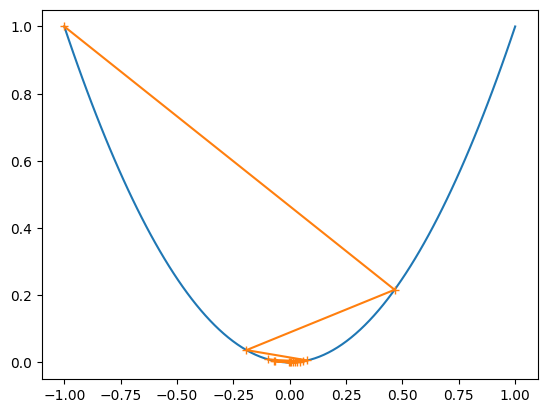

In [5]:
range_x = np.linspace(-1, 1, 100)

plt.plot(range_x, f(range_x))
plt.plot(optimizer.logs_x, optimizer.logs_y, marker = "+")

In [6]:
f = poly1
df = dpoly1

optimizer = OptimizerSGD(.3, max_iter = 100)
optimizer.minimize(f, df, 0)

{'best_x': np.float64(-0.7477185519857664),
 'best_y': np.float64(-0.10546291809213293),
 'x': np.float64(-0.7360745998187281),
 'y': np.float64(-0.10525595676705563),
 't': 28}

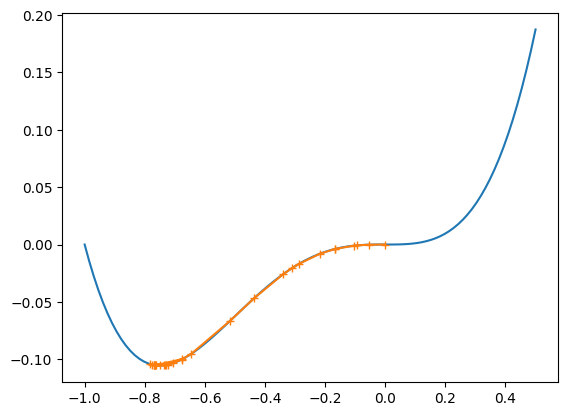

In [7]:
range_x = np.linspace(-1, .5, 100)

plt.plot(range_x, f(range_x))
plt.plot(optimizer.logs_x, optimizer.logs_y, marker = "+")

In [8]:
f = poly2
df = dpoly2

optimizer = OptimizerSGD(1, max_iter = 100)
optimizer.minimize(f, df, 0)

{'best_x': np.float64(0.1668028630113457),
 'best_y': np.float64(-0.011265167512805166),
 'x': np.float64(0.23994478003578495),
 'y': np.float64(-0.0068653102075912215),
 't': 11}

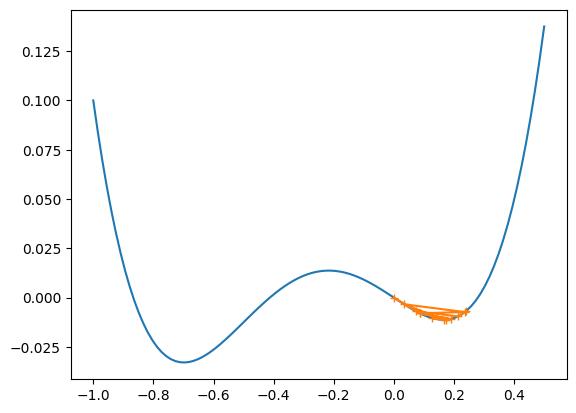

In [9]:
range_x = np.linspace(-1, .5, 100)

plt.plot(range_x, f(range_x))
plt.plot(optimizer.logs_x, optimizer.logs_y, marker = "+")

In [10]:
f = cos_squ
df = dcos_squ

optimizer = OptimizerSGD(1, max_iter = 100)
optimizer.minimize(f, df, 0)

{'best_x': np.float64(-2.5485230750145433),
 'best_y': np.float64(-0.17973198682950753),
 'x': np.float64(-2.7848008528468475),
 'y': np.float64(-0.16151059229626896),
 't': 16}

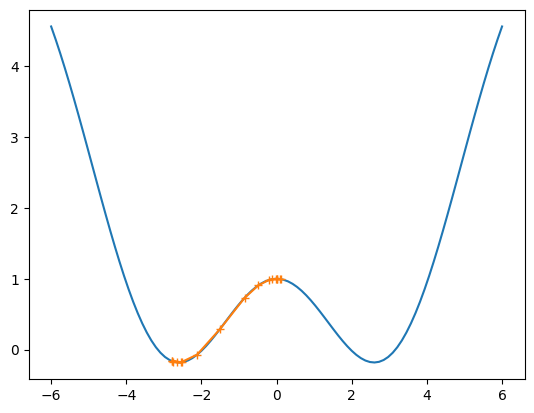

In [11]:
range_x = np.linspace(-6, 6, 100)

plt.plot(range_x, f(range_x))
plt.plot(optimizer.logs_x, optimizer.logs_y, marker = "+")

## Rosenbrock function

We will try to minimize to Rosenbrock function with a SGD. The definition of the Rosenbrock function is:
$$
f(x, y) = 100 (y - x^2)^2 + (1-x)^2 ,
$$
which has a global minimum at $(1, 1)$.

In [12]:
from scipy.optimize import rosen, rosen_der

In [13]:
x, y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-1, 3, 100))

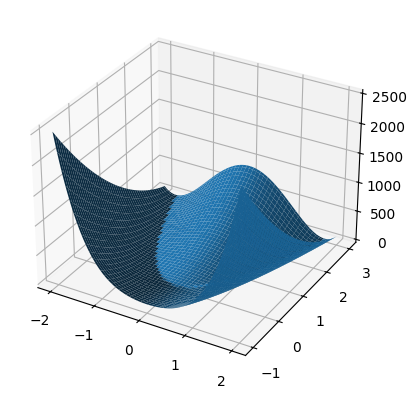

In [14]:
ax = plt.subplot(111, projection='3d')

ax.plot_surface(x, y, rosen([x, y]))

plt.show()

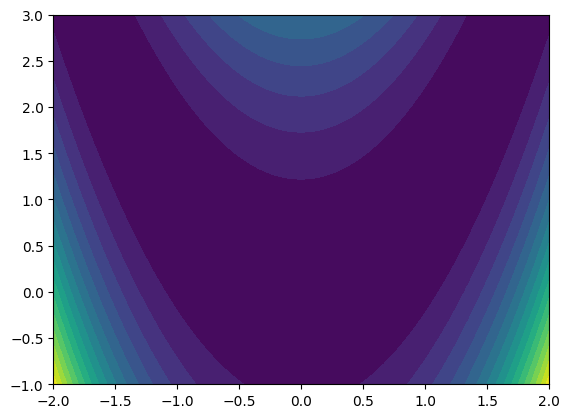

In [15]:
z = rosen([x, y])

fig, ax = plt.subplots()
ax.contourf(x, y, z, levels = 20)

plt.show()

**Question 3**

Find the minimum of the Rosenbrock function by gradient descent. Plot the trajectory on the contour plot.

In [16]:
f = rosen
df = rosen_der

optimizer = OptimizerSGD(.0003, max_iter = 10000, patience = 10)
optimizer.minimize(f, df, np.array([-1.5, -.2]))

{'best_x': array([0.87676049, 0.76817828]),
 'best_y': np.float64(0.01521613915902868),
 'x': array([0.87676049, 0.76817828]),
 'y': np.float64(0.01521613915902868),
 't': 10000}

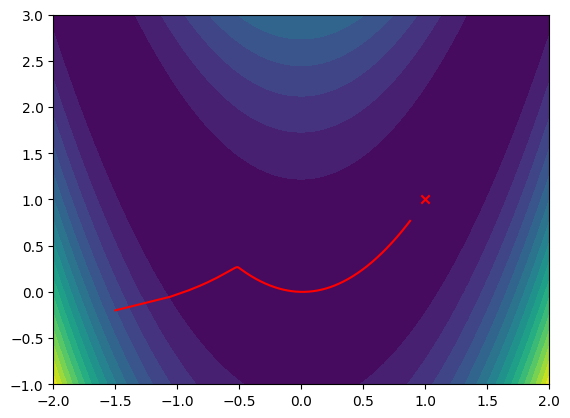

In [17]:
z = rosen([x, y])

fig, ax = plt.subplots()
ax.contourf(x, y, z, levels = 20)
XY = np.stack(optimizer.logs_x)
ax.plot(XY[:,0], XY[:,1], c= "red")
ax.scatter([1], [1], c = "red", marker = "x")

plt.show()